**Cell 1: Imports**

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import layers

2026-06-05 20:45:21.240837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780692321.431280      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780692321.483045      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780692321.920559      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780692321.920595      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780692321.920598      58 computation_placer.cc:177] computation placer alr

**Cell 2: Dataset Path**

In [6]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "cardboard" in dirs:
        print("FOUND:", root)

FOUND: /kaggle/input/datasets/maheshdattatreya/research-qt-3/dataset-resized 2/dataset-resized 2


In [7]:
dataset_path = "/kaggle/input/datasets/maheshdattatreya/research-qt-3/dataset-resized 2/dataset-resized 2"

**Cell 3: Load Dataset**

In [8]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


I0000 00:00:1780692593.673937      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780692593.679761      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2527 files belonging to 6 classes.
Using 505 files for validation.


**Cell 4: Optimize Dataset**

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

**Cell 5: Sustainability Functions**

In [10]:
EDGE_POWER = 5
CLOUD_POWER = 70

results = []

**Cell 6: Evaluation Function**

In [11]:
def evaluate_model(model, name, power):

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=3,
        verbose=1
    )

    training_time = time.time() - start

    loss, accuracy = model.evaluate(
        val_ds,
        verbose=0
    )

    for images, labels in val_ds.take(1):
        sample = images[:1]

    start = time.time()

    for _ in range(100):
        model.predict(sample, verbose=0)

    latency = (time.time()-start)/100

    model.save(f"{name}.keras")

    size_mb = (
        os.path.getsize(f"{name}.keras")
        /(1024*1024)
    )

    bandwidth_cost = size_mb

    energy_per_inference = (
        power * latency / 3600
    )

    sustainability_score = (
        accuracy / energy_per_inference
    )

    results.append([
        name,
        accuracy,
        latency,
        size_mb,
        energy_per_inference,
        sustainability_score
    ])

**Cell 7: Edge AI (MobileNetV2)**

In [16]:
mobilenet = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(6, activation='softmax')
])

mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Cell 8: Train Edge Model**

In [17]:
evaluate_model(
    mobilenet,
    "MobileNetV2_Edge",
    EDGE_POWER
)

Epoch 1/3


I0000 00:00:1780692902.270924     143 service.cc:152] XLA service 0x795024008320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780692902.270977     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780692902.270984     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780692903.231928     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 20:55:11.856969: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:55:12.001121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780692913.980702     143 device_co

11/64 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2300 - loss: 2.0255

2026-06-05 20:55:22.839979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:55:22.977231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


62/64 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.4541 - loss: 1.4692

2026-06-05 20:55:39.321146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:55:39.457754: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:55:39.594436: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 430ms/step - accuracy: 0.5984 - loss: 1.1065 - val_accuracy: 0.7426 - val_loss: 0.7414
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7695 - loss: 0.6263 - val_accuracy: 0.8079 - val_loss: 0.5905
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8274 - loss: 0.4894 - val_accuracy: 0.8178 - val_loss: 0.5463


2026-06-05 20:55:54.606273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:55:54.740444: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


**Cell 9: Cloud AI (EfficientNetB3)**

In [18]:
efficientnet_base = tf.keras.applications.EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300,300,3)
)

efficientnet_base.trainable = False

efficientnet = tf.keras.Sequential([

    layers.Resizing(300,300),

    efficientnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

efficientnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Cell 10: Train Cloud Model**

In [19]:
evaluate_model(
    efficientnet,
    "EfficientNetB3_Cloud",
    CLOUD_POWER
)

Epoch 1/3


2026-06-05 20:57:30.849506: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:57:31.007687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:57:31.489346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:57:31.637600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:57:32.457693: E external/local_xla/xla/stream_

48/64 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4878 - loss: 1.3532

2026-06-05 20:58:00.967177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:01.106146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:01.427828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:01.575733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:02.352972: E external/local_xla/xla/stream_

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.5355 - loss: 1.2535

2026-06-05 20:58:37.733106: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:37.886939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:38.310832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:38.459131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:58:39.261066: E external/local_xla/xla/stream_

64/64 ━━━━━━━━━━━━━━━━━━━━ 103s 970ms/step - accuracy: 0.6968 - loss: 0.9051 - val_accuracy: 0.8317 - val_loss: 0.5531
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.8645 - loss: 0.4454 - val_accuracy: 0.8693 - val_loss: 0.4420
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.8897 - loss: 0.3440 - val_accuracy: 0.8812 - val_loss: 0.3903


2026-06-05 20:59:21.611772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:59:21.746003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:59:22.042654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:59:22.182952: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 20:59:22.924841: E external/local_xla/xla/stream_

**Cell 11: Results Table**

In [20]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Latency_sec",
        "Model_Size_MB",
        "Energy_Per_Inference",
        "Sustainability_Score"
    ]
)

results_df

,Model,Accuracy,Latency_sec,Model_Size_MB,Energy_Per_Inference,Sustainability_Score
0,MobileNetV2_Edge,0.817822,0.182148,9.262560,0.000253,3232.703234
1,EfficientNetB3_Cloud,0.881188,0.253731,42.526018,0.004934,178.607282


**Cell 12: Accuracy Comparison**

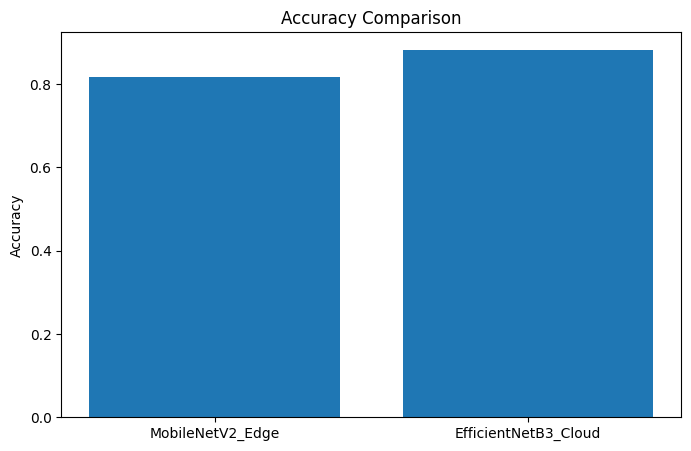

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.show()

**Cell 13: Latency Comparison**

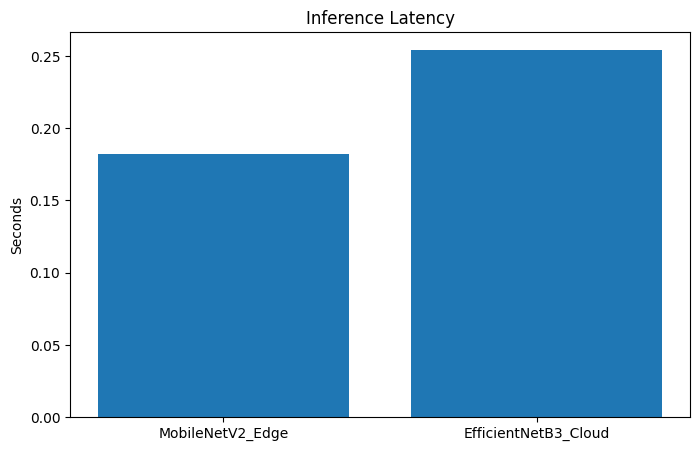

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Latency_sec"]
)

plt.ylabel("Seconds")
plt.title("Inference Latency")

plt.show()

**Cell 14: Bandwidth Comparison**

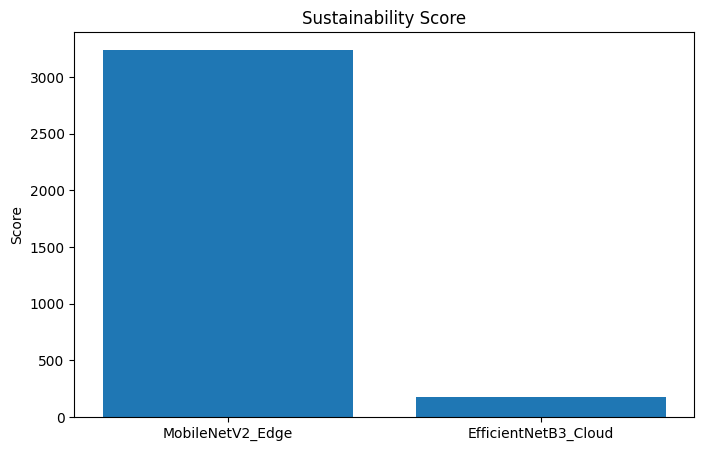

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Sustainability_Score"]
)

plt.ylabel("Score")

plt.title(
    "Sustainability Score"
)

plt.show()

**Cell 15: Sustainability Comparison**

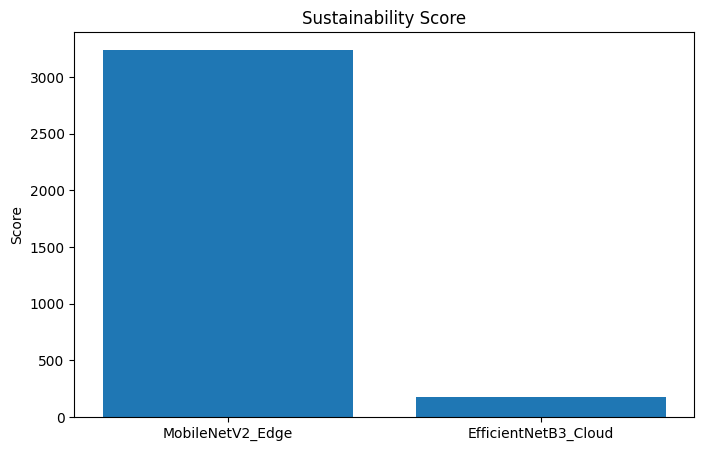

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Sustainability_Score"]
)

plt.ylabel("Score")

plt.title(
    "Sustainability Score"
)

plt.show()

**Cell 16: Trade-off Visualization**

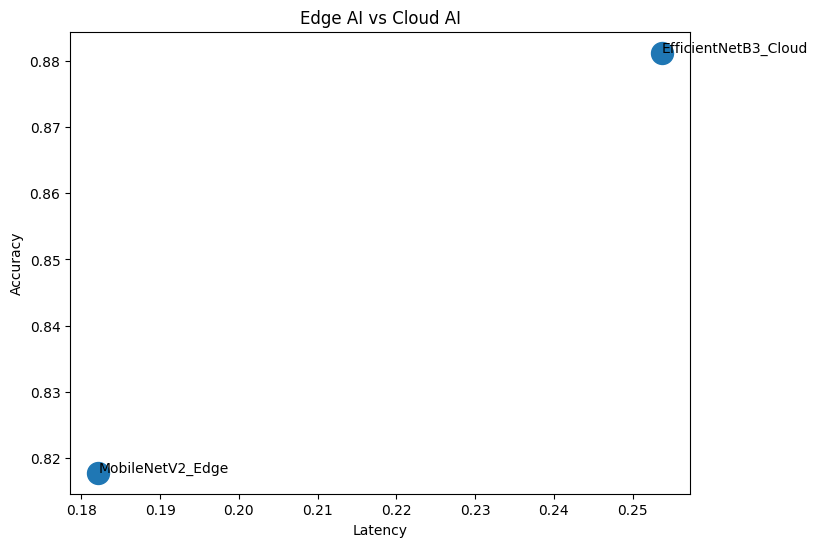

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    results_df["Latency_sec"],
    results_df["Accuracy"],
    s=250
)

for i,row in results_df.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["Latency_sec"],
            row["Accuracy"]
        )
    )

plt.xlabel("Latency")

plt.ylabel("Accuracy")

plt.title(
    "Edge AI vs Cloud AI"
)

plt.show()